# 03 — Sovereign Stress DSA

This notebook extends the validated baseline stochastic DSA with **endogenous sovereign-risk feedback**.

Notebook 02 answered:

> Given the central fiscal path, what range of outcomes results from ordinary historically calibrated macro-financial uncertainty?

Notebook 03 asks:

> What happens when fiscal deterioration itself widens the French sovereign spread, raising refinancing costs and feeding back into debt?

The first objective is to calibrate the sovereign-spread reaction empirically from a euro-area country panel.

The proposed feedback equation is:

\[
s_{i,t}
=
\alpha_i
+
\gamma_t
+
\beta_d d_{i,t-1}
+
\beta_{pb} pb_{i,t}
+
\beta_g g_{i,t}
+
u_{i,t}
\]

where:

- \(s_{i,t}\): 10Y sovereign spread versus Germany;
- \(d_{i,t-1}\): lagged general-government debt/GDP;
- \(pb_{i,t}\): primary balance/GDP;
- \(g_{i,t}\): real GDP growth;
- \(\alpha_i\): country fixed effect;
- \(\gamma_t\): year fixed effect.

Once these coefficients have been inspected and validated, they will feed the recursive stress simulator.

In [2]:
from pathlib import Path
from io import StringIO
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

try:
    import statsmodels.formula.api as smf
except ImportError as exc:
    raise ImportError(
        "Notebook 03 requires statsmodels. "
        "Install it with: pip install statsmodels"
    ) from exc


PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

STRESS_DIR = (
    PROCESSED_DIR
    / "sovereign_stress"
)

STRESS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

from src.models.stochastic_dsa import (
    build_market_curves_from_path,
    generate_calibrated_stochastic_path,
    percentile_frame,
    risk_probability_table,
    run_monte_carlo,
    simulate_stochastic_gg_dsa,
)

RANDOM_SEED = 42

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\mikel\Desktop\french_oat_model


## 1. Load the Notebook 02 baseline Monte Carlo benchmark

Notebook 03 should not rerun the ordinary-times Monte Carlo merely to reproduce the benchmark. We load the compact outputs saved by Notebook 02.

In [3]:
MONTE_CARLO_DIR = (
    PROCESSED_DIR
    / "monte_carlo"
)

MC_PATH = MONTE_CARLO_DIR / "monte_carlo_10000_paths.npz"
DEBT_FAN_PATH = MONTE_CARLO_DIR / "debt_fan_percentiles.csv"
INTEREST_FAN_PATH = MONTE_CARLO_DIR / "interest_fan_percentiles.csv"
OAT_FAN_PATH = MONTE_CARLO_DIR / "oat_fan_percentiles.csv"
RISK_PATH = MONTE_CARLO_DIR / "risk_probabilities.csv"

required_files = [
    MC_PATH,
    DEBT_FAN_PATH,
    INTEREST_FAN_PATH,
    OAT_FAN_PATH,
    RISK_PATH,
]

missing_files = [
    path
    for path in required_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Notebook 02 Monte Carlo outputs are missing:\n"
        + "\n".join(
            str(path)
            for path in missing_files
        )
    )

mc02 = np.load(MC_PATH)

debt_fan_02 = pd.read_csv(DEBT_FAN_PATH)
interest_fan_02 = pd.read_csv(INTEREST_FAN_PATH)
oat_fan_02 = pd.read_csv(OAT_FAN_PATH)
risk_02 = pd.read_csv(RISK_PATH)

print(
    "Notebook 02 path matrix:",
    mc02["debt_gdp"].shape,
)

risk_02[
    [
        "metric",
        "probability_pct",
    ]
]

Notebook 02 path matrix: (10000, 15)


,metric,probability_pct
0,Debt/GDP > 130% in 2041,35.69
1,Debt/GDP > 150% in 2041,2.45
2,Debt/GDP > 175% in 2041,0.00
3,Debt/GDP above 2026 level in 2041,72.13
4,Debt rises >20 pp within any 5-year window,3.02
5,Interest/GDP exceeds 4% at least once,54.30
6,Interest/GDP exceeds 5% at least once,14.61
7,30Y OAT exceeds 6% at least once,35.96
8,30Y OAT exceeds 7% at least once,5.21
9,30Y OAT > 6% in 2041,5.17


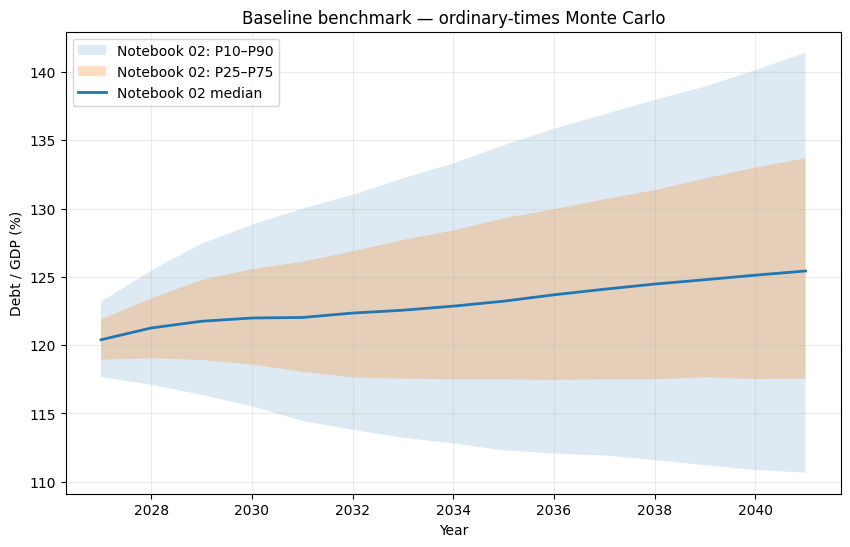

In [4]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.fill_between(
    debt_fan_02["year"],
    debt_fan_02["p10"] * 100,
    debt_fan_02["p90"] * 100,
    alpha=0.15,
    label="Notebook 02: P10–P90",
)

ax.fill_between(
    debt_fan_02["year"],
    debt_fan_02["p25"] * 100,
    debt_fan_02["p75"] * 100,
    alpha=0.25,
    label="Notebook 02: P25–P75",
)

ax.plot(
    debt_fan_02["year"],
    debt_fan_02["p50"] * 100,
    linewidth=2,
    label="Notebook 02 median",
)

ax.set_title(
    "Baseline benchmark — ordinary-times Monte Carlo"
)

ax.set_xlabel("Year")
ax.set_ylabel("Debt / GDP (%)")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

## 2. Euro-area sovereign panel

Germany is the benchmark used to construct spreads and is therefore not itself included as a dependent-variable observation.

The first panel uses France, Italy, Spain, Belgium, Portugal, Austria, Netherlands, Finland, Ireland and Greece over 2000–2025 where data permit.

In [5]:
COUNTRIES = {
    "France": {
        "ecb": "FR",
        "eurostat": "FR",
        "ameco": "FRA",
    },
    "Italy": {
        "ecb": "IT",
        "eurostat": "IT",
        "ameco": "ITA",
    },
    "Spain": {
        "ecb": "ES",
        "eurostat": "ES",
        "ameco": "ESP",
    },
    "Belgium": {
        "ecb": "BE",
        "eurostat": "BE",
        "ameco": "BEL",
    },
    "Portugal": {
        "ecb": "PT",
        "eurostat": "PT",
        "ameco": "PRT",
    },
    "Austria": {
        "ecb": "AT",
        "eurostat": "AT",
        "ameco": "AUT",
    },
    "Netherlands": {
        "ecb": "NL",
        "eurostat": "NL",
        "ameco": "NLD",
    },
    "Finland": {
        "ecb": "FI",
        "eurostat": "FI",
        "ameco": "FIN",
    },
    "Ireland": {
        "ecb": "IE",
        "eurostat": "IE",
        "ameco": "IRL",
    },
    "Greece": {
        "ecb": "GR",
        "eurostat": "EL",
        "ameco": "GRC",
    },
}

GERMANY_ECB_CODE = "DE"

PANEL_START_YEAR = 2000
PANEL_END_YEAR = 2025

print("Panel countries:", len(COUNTRIES))

Panel countries: 10


## 3. Cached public-data downloaders

The panel uses:

- ECB IRS harmonised monthly 10Y government yields;
- Eurostat `gov_10dd_edpt1` for Maastricht debt/GDP;
- Eurostat `nama_10_gdp` for real GDP growth;
- AMECO via DBnomics for primary balance/GDP.

All downloads are cached under `data/raw/sovereign_stress/`.

In [6]:
STRESS_RAW_DIR = (
    RAW_DIR
    / "sovereign_stress"
)

ECB_CACHE_DIR = STRESS_RAW_DIR / "ecb"
EUROSTAT_CACHE_DIR = STRESS_RAW_DIR / "eurostat"
AMECO_CACHE_DIR = STRESS_RAW_DIR / "ameco"


def create_retry_session():
    retry_strategy = Retry(
        total=6,
        connect=6,
        read=6,
        status=6,
        backoff_factor=1.5,
        status_forcelist=[
            429,
            500,
            502,
            503,
            504,
        ],
        allowed_methods=frozenset(["GET"]),
        respect_retry_after_header=True,
    )

    adapter = HTTPAdapter(
        max_retries=retry_strategy
    )

    session = requests.Session()
    session.mount("https://", adapter)

    session.headers.update({
        "User-Agent":
            "french-oat-model/1.0",
    })

    return session


HTTP_SESSION = create_retry_session()

In [7]:
def fetch_ecb_10y(
    country_code,
    start_period="2000-01",
    end_period="2025-12",
    force_refresh=False,
):
    """
    Fetch the ECB monthly harmonised 10Y long-term rate.
    """

    ECB_CACHE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    cache_path = (
        ECB_CACHE_DIR
        / (
            f"ecb_10y_{country_code}_"
            f"{start_period}_{end_period}.csv"
        )
    )

    if (
        cache_path.exists()
        and not force_refresh
    ):
        return pd.read_csv(
            cache_path,
            parse_dates=["TIME_PERIOD"],
        )

    series_key = (
        f"M.{country_code}."
        "L.L40.CI.0000.EUR.N.Z"
    )

    url = (
        "https://data-api.ecb.europa.eu/"
        f"service/data/IRS/{series_key}"
    )

    response = HTTP_SESSION.get(
        url,
        params={
            "startPeriod": start_period,
            "endPeriod": end_period,
            "format": "csvdata",
            "detail": "dataonly",
        },
        timeout=(10, 180),
    )

    response.raise_for_status()

    df = pd.read_csv(
        StringIO(response.text)
    )

    required = {
        "TIME_PERIOD",
        "OBS_VALUE",
    }

    missing = (
        required
        - set(df.columns)
    )

    if missing:
        raise ValueError(
            f"ECB response missing: {missing}"
        )

    df = df[
        [
            "TIME_PERIOD",
            "OBS_VALUE",
        ]
    ].copy()

    df["TIME_PERIOD"] = pd.to_datetime(
        df["TIME_PERIOD"],
        errors="coerce",
    )

    df["OBS_VALUE"] = pd.to_numeric(
        df["OBS_VALUE"],
        errors="coerce",
    )

    df = (
        df
        .dropna()
        .sort_values("TIME_PERIOD")
        .reset_index(drop=True)
    )

    df.to_csv(
        cache_path,
        index=False,
    )

    return df


def monthly_rate_to_annual(
    df,
    value_name,
):
    result = df.copy()

    result["year"] = (
        result["TIME_PERIOD"]
        .dt.year
    )

    result[value_name] = (
        result["OBS_VALUE"]
        / 100
    )

    return (
        result[
            [
                "year",
                value_name,
            ]
        ]
        .groupby(
            "year",
            as_index=False,
        )[value_name]
        .mean()
    )

In [8]:
def _jsonstat_category_labels(
    category_index,
):
    if isinstance(
        category_index,
        dict,
    ):
        return [
            label
            for label, _
            in sorted(
                category_index.items(),
                key=lambda x: x[1],
            )
        ]

    return list(category_index)


def fetch_eurostat_single_series(
    dataset_code,
    filters,
    value_name,
    force_refresh=False,
):
    """
    Fetch a Eurostat JSON-stat series where all dimensions
    other than time are reduced to one category.
    """

    EUROSTAT_CACHE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    filter_string = "_".join(
        f"{key}-{value}"
        for key, value
        in sorted(filters.items())
    )

    cache_path = (
        EUROSTAT_CACHE_DIR
        / f"{dataset_code}_{filter_string}.csv"
    )

    if (
        cache_path.exists()
        and not force_refresh
    ):
        return pd.read_csv(
            cache_path
        )

    url = (
        "https://ec.europa.eu/"
        "eurostat/api/dissemination/"
        "statistics/1.0/data/"
        f"{dataset_code}"
    )

    response = HTTP_SESSION.get(
        url,
        params={
            "lang": "EN",
            **filters,
        },
        timeout=(10, 180),
    )

    response.raise_for_status()

    data = response.json()

    dimension_ids = data["id"]
    dimension_sizes = data["size"]

    if "time" not in dimension_ids:
        raise ValueError(
            "Eurostat response has no time dimension."
        )

    time_position = (
        dimension_ids.index("time")
    )

    for i, dimension in enumerate(
        dimension_ids
    ):
        if (
            dimension != "time"
            and dimension_sizes[i] != 1
        ):
            raise ValueError(
                f"Dimension {dimension!r} "
                "was not reduced to one category."
            )

    years = _jsonstat_category_labels(
        data[
            "dimension"
        ][
            "time"
        ][
            "category"
        ][
            "index"
        ]
    )

    values = data["value"]

    rows = []

    for time_coordinate, year in enumerate(
        years
    ):
        coordinates = [
            0
            for _ in dimension_ids
        ]

        coordinates[
            time_position
        ] = time_coordinate

        flat_index = int(
            np.ravel_multi_index(
                tuple(coordinates),
                tuple(dimension_sizes),
                order="C",
            )
        )

        if isinstance(values, dict):
            value = values.get(
                str(flat_index),
                np.nan,
            )
        else:
            value = (
                values[flat_index]
                if flat_index < len(values)
                else np.nan
            )

        rows.append({
            "year": int(year),
            value_name: value,
        })

    result = pd.DataFrame(rows)

    result[value_name] = pd.to_numeric(
        result[value_name],
        errors="coerce",
    )

    result.to_csv(
        cache_path,
        index=False,
    )

    return result

In [9]:
def fetch_ameco_primary_balance(
    ameco_country_code,
    force_refresh=False,
):
    """
    Fetch AMECO UBLGI:
    general-government primary balance as % GDP.
    """

    AMECO_CACHE_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    cache_path = (
        AMECO_CACHE_DIR
        / (
            f"primary_balance_"
            f"{ameco_country_code}.csv"
        )
    )

    if (
        cache_path.exists()
        and not force_refresh
    ):
        return pd.read_csv(
            cache_path
        )

    series_code = (
        f"{ameco_country_code}."
        "1.0.319.0.UBLGI"
    )

    url = (
        "https://api.db.nomics.world/"
        "v22/series/"
        f"AMECO/UBLGI/{series_code}"
    )

    response = HTTP_SESSION.get(
        url,
        params={"observations": 1},
        timeout=(10, 180),
    )

    response.raise_for_status()

    payload = response.json()

    docs = (
        payload
        .get("series", {})
        .get("docs", [])
    )

    if not docs:
        raise ValueError(
            f"No AMECO primary-balance "
            f"series for {ameco_country_code}."
        )

    series = docs[0]

    result = pd.DataFrame({
        "year": pd.to_numeric(
            series["period"],
            errors="coerce",
        ),
        "primary_balance_gdp": pd.to_numeric(
            series["value"],
            errors="coerce",
        ),
    })

    result = (
        result
        .dropna()
        .copy()
    )

    result["year"] = (
        result["year"]
        .astype(int)
    )

    result["primary_balance_gdp"] /= 100

    result.to_csv(
        cache_path,
        index=False,
    )

    return result

## 4. Build the sovereign panel

All model variables are stored as decimals:

- `1.20` debt/GDP = 120%;
- `0.03` spread = 3%;
- `-0.02` primary balance = -2% of GDP.

In [10]:
bund_monthly = fetch_ecb_10y(
    GERMANY_ECB_CODE,
)

bund_annual = (
    monthly_rate_to_annual(
        bund_monthly,
        "bund_10y",
    )
)

bund_annual = (
    bund_annual[
        bund_annual["year"].between(
            PANEL_START_YEAR,
            PANEL_END_YEAR,
        )
    ]
    .reset_index(drop=True)
)

bund_annual.head()

,year,bund_10y
0,2000,0.052633
1,2001,0.047975
2,2002,0.047825
3,2003,0.040708
4,2004,0.040367


In [11]:
def build_country_panel(
    country_name,
    codes,
):
    """
    Build one country's annual sovereign-risk panel.
    """

    rate_monthly = fetch_ecb_10y(
        codes["ecb"]
    )

    rate_annual = (
        monthly_rate_to_annual(
            rate_monthly,
            "sovereign_10y",
        )
    )

    rates = (
        rate_annual
        .merge(
            bund_annual,
            on="year",
            how="inner",
            validate="one_to_one",
        )
    )

    rates["spread_10y"] = (
        rates["sovereign_10y"]
        - rates["bund_10y"]
    )

    debt = (
        fetch_eurostat_single_series(
            dataset_code="gov_10dd_edpt1",
            filters={
                "freq": "A",
                "unit": "PC_GDP",
                "sector": "S13",
                "na_item": "GD",
                "geo": codes["eurostat"],
            },
            value_name="debt_gdp",
        )
    )

    debt["debt_gdp"] /= 100

    growth = (
        fetch_eurostat_single_series(
            dataset_code="nama_10_gdp",
            filters={
                "freq": "A",
                "unit": "CLV_PCH_PRE",
                "na_item": "B1GQ",
                "geo": codes["eurostat"],
            },
            value_name="real_growth",
        )
    )

    growth["real_growth"] /= 100

    primary_balance = (
        fetch_ameco_primary_balance(
            codes["ameco"]
        )
    )

    result = (
        rates
        .merge(
            debt,
            on="year",
            how="inner",
        )
        .merge(
            growth,
            on="year",
            how="inner",
        )
        .merge(
            primary_balance,
            on="year",
            how="inner",
        )
    )

    result = (
        result[
            result["year"].between(
                PANEL_START_YEAR,
                PANEL_END_YEAR,
            )
        ]
        .copy()
    )

    result["country"] = country_name

    return result[
        [
            "country",
            "year",
            "sovereign_10y",
            "bund_10y",
            "spread_10y",
            "debt_gdp",
            "primary_balance_gdp",
            "real_growth",
        ]
    ]


panel_parts = []

for country_name, codes in (
    COUNTRIES.items()
):
    print(
        f"Building {country_name}..."
    )

    panel_parts.append(
        build_country_panel(
            country_name,
            codes,
        )
    )

sovereign_panel = (
    pd.concat(
        panel_parts,
        ignore_index=True,
    )
    .sort_values(
        [
            "country",
            "year",
        ]
    )
    .reset_index(drop=True)
)

sovereign_panel

Building France...
Building Italy...
Building Spain...
Building Belgium...
Building Portugal...
Building Austria...
Building Netherlands...
Building Finland...
Building Ireland...
Building Greece...


,country,year,sovereign_10y,bund_10y,spread_10y,debt_gdp,primary_balance_gdp,real_growth
0,Austria,2000,0.055554,0.052633,0.002921,0.666,0.011766,0.032
1,Austria,2001,0.050802,0.047975,0.002827,0.672,0.029180,0.013
2,Austria,2002,0.049638,0.047825,0.001813,0.674,0.020522,0.015
3,Austria,2003,0.041409,0.040708,0.000700,0.664,0.013674,0.011
4,Austria,2004,0.041309,0.040367,0.000942,0.659,-0.018884,0.026
...,...,...,...,...,...,...,...,...
255,Spain,2021,0.003474,-0.003735,0.007209,1.157,-0.045330,0.067
256,Spain,2022,0.021805,0.011424,0.010381,1.093,-0.022771,0.064
257,Spain,2023,0.034762,0.024342,0.010420,1.052,-0.009665,0.024
258,Spain,2024,0.031486,0.023205,0.008281,1.016,-0.007824,0.037


In [12]:
required_columns = [
    "country",
    "year",
    "spread_10y",
    "debt_gdp",
    "primary_balance_gdp",
    "real_growth",
]

assert not (
    sovereign_panel[
        required_columns
    ]
    .isna()
    .any()
    .any()
), (
    "NULL values remain in the merged panel."
)

assert not sovereign_panel.duplicated(
    subset=[
        "country",
        "year",
    ]
).any(), (
    "Duplicate country-year observations found."
)

panel_counts = (
    sovereign_panel
    .groupby("country")
    .size()
    .sort_values(
        ascending=False
    )
    .rename("observations")
)

print(panel_counts)

assert (
    panel_counts >= 15
).all(), (
    "At least one country has fewer than "
    "15 usable annual observations."
)

panel_path = (
    STRESS_DIR
    / "euro_area_sovereign_panel.csv"
)

sovereign_panel.to_csv(
    panel_path,
    index=False,
)

print(
    "\nPanel saved to:",
    panel_path,
)

country
Austria        26
Belgium        26
Finland        26
France         26
Greece         26
Ireland        26
Italy          26
Netherlands    26
Portugal       26
Spain          26
Name: observations, dtype: int64

Panel saved to: c:\Users\mikel\Desktop\french_oat_model\data\processed\sovereign_stress\euro_area_sovereign_panel.csv


## 5. Two-way fixed-effects spread regression

Debt enters with a one-year lag.

The model includes country fixed effects and year fixed effects, with standard errors clustered by country.

In [13]:
regression_panel = (
    sovereign_panel
    .copy()
)

regression_panel["debt_gdp_lag"] = (
    regression_panel
    .groupby("country")[
        "debt_gdp"
    ]
    .shift(1)
)

regression_panel = (
    regression_panel
    .dropna(
        subset=[
            "spread_10y",
            "debt_gdp_lag",
            "primary_balance_gdp",
            "real_growth",
        ]
    )
    .reset_index(drop=True)
)

print(
    "Regression observations:",
    len(regression_panel),
)

print(
    "Countries:",
    regression_panel["country"].nunique(),
)

print(
    "Years:",
    regression_panel["year"].min(),
    "to",
    regression_panel["year"].max(),
)

Regression observations: 250
Countries: 10
Years: 2001 to 2025


In [14]:
SPREAD_FORMULA = (
    "spread_10y ~ "
    "debt_gdp_lag "
    "+ primary_balance_gdp "
    "+ real_growth "
    "+ C(country) "
    "+ C(year)"
)

spread_model = (
    smf.ols(
        formula=SPREAD_FORMULA,
        data=regression_panel,
    )
    .fit(
        cov_type="cluster",
        cov_kwds={
            "groups":
                regression_panel["country"]
        },
    )
)

print(
    spread_model.summary()
)

                            OLS Regression Results                            
Dep. Variable:             spread_10y   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                     5.052
Date:                Sun, 04 Oct 2026   Prob (F-statistic):             0.0121
Time:                        15:04:05   Log-Likelihood:                 738.04
No. Observations:                 250   AIC:                            -1402.
Df Residuals:                     213   BIC:                            -1272.
Df Model:                          36                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

c:\Users\mikel\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:1988: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 36, but rank is 9
  res = self.wald_test(


## 6. Translate the coefficients into economically readable effects

Because all variables are decimals:

- +10 percentage points of debt/GDP = `+0.10`;
- +1 percentage point of primary balance = `+0.01`;
- -1 percentage point of real growth = `-0.01`.

Spread effects are reported in basis points.

In [15]:
beta_debt = (
    spread_model.params[
        "debt_gdp_lag"
    ]
)

beta_pb = (
    spread_model.params[
        "primary_balance_gdp"
    ]
)

beta_growth = (
    spread_model.params[
        "real_growth"
    ]
)

economic_effects = pd.DataFrame({
    "shock": [
        "+10 pp debt/GDP",
        "+1 pp primary balance/GDP",
        "-1 pp real GDP growth",
    ],
    "spread_effect_bp": [
        beta_debt
        * 0.10
        * 10_000,

        beta_pb
        * 0.01
        * 10_000,

        beta_growth
        * (-0.01)
        * 10_000,
    ],
})

economic_effects.round(2)

,shock,spread_effect_bp
0,+10 pp debt/GDP,33.08
1,+1 pp primary balance/GDP,-2.07
2,-1 pp real GDP growth,27.70


In [16]:
panel_no_greece = (
    regression_panel[
        regression_panel["country"]
        != "Greece"
    ]
    .copy()
)

spread_model_no_greece = (
    smf.ols(
        formula=SPREAD_FORMULA,
        data=panel_no_greece,
    )
    .fit(
        cov_type="cluster",
        cov_kwds={
            "groups":
                panel_no_greece["country"]
        },
    )
)

coefficient_comparison = pd.DataFrame({
    "coefficient": [
        "debt_gdp_lag",
        "primary_balance_gdp",
        "real_growth",
    ],
    "full_panel": [
        spread_model.params[
            "debt_gdp_lag"
        ],
        spread_model.params[
            "primary_balance_gdp"
        ],
        spread_model.params[
            "real_growth"
        ],
    ],
    "exclude_greece": [
        spread_model_no_greece.params[
            "debt_gdp_lag"
        ],
        spread_model_no_greece.params[
            "primary_balance_gdp"
        ],
        spread_model_no_greece.params[
            "real_growth"
        ],
    ],
})

coefficient_comparison[
    "full_panel_effect_bp"
] = [
    coefficient_comparison.loc[
        0,
        "full_panel",
    ]
    * 0.10
    * 10_000,

    coefficient_comparison.loc[
        1,
        "full_panel",
    ]
    * 0.01
    * 10_000,

    coefficient_comparison.loc[
        2,
        "full_panel",
    ]
    * (-0.01)
    * 10_000,
]

coefficient_comparison[
    "exclude_greece_effect_bp"
] = [
    coefficient_comparison.loc[
        0,
        "exclude_greece",
    ]
    * 0.10
    * 10_000,

    coefficient_comparison.loc[
        1,
        "exclude_greece",
    ]
    * 0.01
    * 10_000,

    coefficient_comparison.loc[
        2,
        "exclude_greece",
    ]
    * (-0.01)
    * 10_000,
]

coefficient_comparison.round(3)

,coefficient,full_panel,exclude_greece,full_panel_effect_bp,exclude_greece_effect_bp
0,debt_gdp_lag,0.033,0.023,33.076,22.762
1,primary_balance_gdp,-0.021,-0.054,-2.074,-5.367
2,real_growth,-0.277,-0.083,27.701,8.320


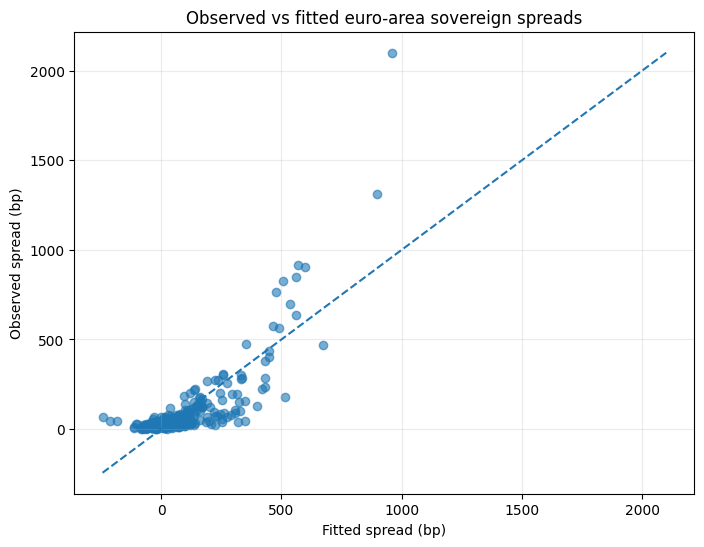

In [17]:
regression_panel[
    "fitted_spread_10y"
] = (
    spread_model.predict(
        regression_panel
    )
)

regression_panel[
    "residual_spread_10y"
] = (
    regression_panel[
        "spread_10y"
    ]
    -
    regression_panel[
        "fitted_spread_10y"
    ]
)

fig, ax = plt.subplots(
    figsize=(8, 6)
)

ax.scatter(
    regression_panel[
        "fitted_spread_10y"
    ]
    * 10_000,
    regression_panel[
        "spread_10y"
    ]
    * 10_000,
    alpha=0.6,
)

lims = [
    min(
        regression_panel[
            "fitted_spread_10y"
        ].min(),
        regression_panel[
            "spread_10y"
        ].min(),
    )
    * 10_000,

    max(
        regression_panel[
            "fitted_spread_10y"
        ].max(),
        regression_panel[
            "spread_10y"
        ].max(),
    )
    * 10_000,
]

ax.plot(
    lims,
    lims,
    linestyle="--",
)

ax.set_title(
    "Observed vs fitted euro-area sovereign spreads"
)

ax.set_xlabel(
    "Fitted spread (bp)"
)

ax.set_ylabel(
    "Observed spread (bp)"
)

ax.grid(alpha=0.25)

plt.show()

# Current stopping point

Before implementing the recursive sovereign-stress simulator, inspect:

1. the sign and magnitude of `beta_debt`;
2. the sign and magnitude of `beta_pb`;
3. the sign and magnitude of `beta_growth`;
4. whether those coefficients remain broadly similar when Greece is excluded;
5. the observed-vs-fitted spread diagnostics.

We should **not** hard-code the debt-to-spread feedback until these estimates have been inspected.

The next stage will convert accepted coefficients into a France-specific deviation equation:

\[
\Delta s_t
=
\beta_d
(d_{t-1}-d_{t-1}^{central})
+
\beta_{pb}
(pb_t-pb_t^{central})
+
\beta_g
(g_t-g_t^{central})
\]

and feed that spread adjustment recursively into the AFT refinancing engine and general-government DSA.

In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess


# ============================================================
# Calibration curve: observed vs fitted
# ============================================================

x = (
    regression_panel[
        "fitted_spread_10y"
    ].to_numpy()
    * 10_000
)

y = (
    regression_panel[
        "spread_10y"
    ].to_numpy()
    * 10_000
)


lowess_fit = lowess(
    endog=y,
    exog=x,
    frac=0.35,
    it=2,
    return_sorted=True,
)


fig, ax = plt.subplots(
    figsize=(8, 6)
)


ax.scatter(
    x,
    y,
    alpha=0.5,
    label="Observations",
)


# Perfect calibration
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max()),
]


ax.plot(
    lims,
    lims,
    linestyle="--",
    label="Perfect calibration",
)


# Empirical nonlinear calibration
ax.plot(
    lowess_fit[:, 0],
    lowess_fit[:, 1],
    linewidth=2,
    label="LOWESS calibration",
)


ax.set_title(
    "Observed vs fitted euro-area sovereign spreads"
)

ax.set_xlabel(
    "Fitted spread (bp)"
)

ax.set_ylabel(
    "Observed spread (bp)"
)

ax.grid(
    alpha=0.25
)

ax.legend()

plt.show()